# Human-in-the-Loop

LLM이 자율적으로 행동할수록 **사람의 통제**가 중요해진다. 이번 강의에서는 LangGraph의 interrupt와 Checkpointer를 활용해 사람이 개입하는 워크플로우를 구현한다.

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

## 사람의 개입이 필요한 이유

Agent가 Tool을 자유롭게 호출할 수 있다면, 다음과 같은 상황에서 문제가 생긴다.

| 작업 | 위험도 | 이유 |
|------|--------|------|
| 결제 실행 | 높음 | 되돌리기 어려움 |
| 이메일 발송 | 높음 | 발송 후 취소 불가 |
| DB 레코드 삭제 | 높음 | 데이터 복구 비용 큼 |
| 파일 쓰기/삭제 | 중간 | 덮어쓰기 시 복원 어려움 |
| 웹 검색 | 낮음 | 부작용 없음 |

핵심 원칙: **되돌리기 어려운 작업 전에는 반드시 사람의 승인을 받는다.**

## interrupt 기본

LangGraph는 `compile()` 시 `interrupt_before` 또는 `interrupt_after` 파라미터로 특정 노드 전후에 그래프 실행을 중단할 수 있다.

```
START → agent → (중단) → tools → END
                  ↑
           사람이 승인하면 계속
```

**Checkpointer가 필수**다. 중단 시점의 상태를 저장해야 이어서 실행할 수 있기 때문이다.

In [2]:
from typing import Annotated, TypedDict
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver


@tool
def send_payment(amount: int, recipient: str) -> str:
    """결제를 실행한다."""
    return f"{recipient}에게 {amount}원 결제 완료."


class State(TypedDict):
    messages: Annotated[list, add_messages]


tools = [send_payment]
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0).bind_tools(tools)


def agent(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


graph_builder = StateGraph(State)
graph_builder.add_node("agent", agent)
graph_builder.add_node("tools", ToolNode(tools))
graph_builder.add_edge(START, "agent")
graph_builder.add_conditional_edges("agent", tools_condition)
graph_builder.add_edge("tools", "agent")

# interrupt_before=["tools"] → tools 노드 실행 전에 중단
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory, interrupt_before=["tools"])

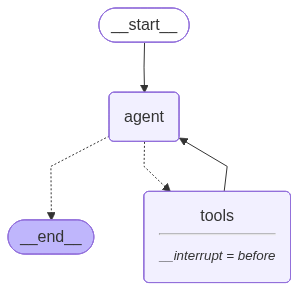

In [3]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
# 실행 - tools 노드 직전에 중단된다
config = {"configurable": {"thread_id": "payment-1"}}

result = graph.invoke(
    {"messages": [("user", "홍길동에게 50000원 결제해줘")]},
    config,
)

# 중단 없이 끝났다면 AI의 텍스트 응답이 돌아오지만,
# interrupt_before 때문에 tools 노드 진입 직전에 중단되어 invoke()가 리턴된다.
# 따라서 마지막 메시지는 tool_calls가 포함된 AI 메시지다.
last_msg = result["messages"][-1]
print(f"타입: {last_msg.type}")
print(f"Tool 호출: {last_msg.tool_calls}")
print()
print("그래프가 tools 노드 직전에서 중단되었다.")

타입: ai
Tool 호출: [{'name': 'send_payment', 'args': {'amount': 50000, 'recipient': '홍길동'}, 'id': 'call_aLmBoR7FSTsXyD0iWPgbmHQ5', 'type': 'tool_call'}]

그래프가 tools 노드 직전에서 중단되었다.


## 승인 워크플로우 구현

중단된 그래프를 이어서 실행하려면 `graph.invoke(None, config)`를 호출한다. `None`을 넘기면 새로운 입력 없이 중단된 지점부터 계속 진행한다.

먼저 `graph.get_state(config)`로 현재 상태를 확인할 수 있다. 반환되는 `StateSnapshot` 객체에서 새로 알아둘 속성:

- **`state.next`** — 다음에 실행될 노드 이름의 튜플. 중단 중이면 `('tools',)`처럼 대기 중인 노드가 표시되고, 실행이 끝났으면 빈 튜플 `()`이다.

In [5]:
# 현재 상태 확인
state = graph.get_state(config)
print(f"다음 실행될 노드: {state.next}")
print(f"대기 중인 tool 호출: {state.values['messages'][-1].tool_calls[0]['name']}")
print(f"  인자: {state.values['messages'][-1].tool_calls[0]['args']}")

다음 실행될 노드: ('tools',)
대기 중인 tool 호출: send_payment
  인자: {'amount': 50000, 'recipient': '홍길동'}


In [6]:
# 승인: None을 넘기면 중단된 지점에서 이어서 실행
user_input = input("승인하시겠습니까? (y/n): ")

if user_input.lower() == "y":
    result = graph.invoke(None, config)
    print(result["messages"][-1].content)
else:
    print("사용자가 거부했습니다.")

홍길동에게 50,000원이 결제되었습니다.


### 거부 시 상태 수정 후 재실행

사용자가 거부하면 `update_state`로 상태를 수정해서 다른 경로로 진행할 수 있다.

현재 그래프는 tools 노드 직전에서 중단된 상태다. 이때 거부 흐름은 다음과 같다.

1. tool 호출을 허용하지 않으므로, 취소되었다는 AI 메시지를 직접 넣는다
2. `as_node="agent"` → 이 메시지를 **agent가 생성한 것으로 취급**한다. 즉 대기 중이던 tools 호출을 이 메시지가 대체한다.
3. agent의 라우팅(`should_continue`)이 적용된다 → tool_calls가 없으므로 `END`로 종료

`as_node`에는 그래프에 등록된 아무 노드 이름이나 넣을 수 있다. 어떤 노드를 지정하느냐에 따라 그 노드의 다음 엣지를 따라간다.

In [7]:
# 새로운 스레드에서 다시 시작
config2 = {"configurable": {"thread_id": "payment-2"}}

result = graph.invoke(
    {"messages": [("user", "홍길동에게 50000원 결제해줘")]},
    config2,
)

print("중단됨. 거부 처리를 시작한다.")

# 상태를 수정: tool 호출 대신 거부 메시지로 교체
from langchain_core.messages import AIMessage

graph.update_state(
    config2,
    {"messages": [AIMessage(content="결제가 사용자에 의해 취소되었습니다.")]},
    as_node="agent",  # agent 노드가 이 메시지를 생성한 것으로 처리
)

# 상태 확인 - 더 이상 실행할 노드가 없다
state = graph.get_state(config2)
print(f"다음 노드: {state.next}")  # () - 빈 튜플
print(f"마지막 메시지: {state.values['messages'][-1].content}")

중단됨. 거부 처리를 시작한다.
다음 노드: ()
마지막 메시지: 결제가 사용자에 의해 취소되었습니다.


## Tool 실행 보안

실무에서는 모든 Tool에 interrupt를 걸면 UX가 나빠진다. **위험도에 따라 분류**하는 것이 좋다.

| 보안 레벨 | 동작 | 예시 |
|-----------|------|------|
| 안전 | 자동 실행 | 검색, 날씨 조회, 계산 |
| 주의 | 로깅 후 자동 실행 | 파일 읽기, API 호출 |
| 위험 | interrupt 필수 | 결제, 삭제, 이메일 발송 |

패턴: 위험한 Tool만 별도 노드로 분리하고 해당 노드에만 interrupt를 건다. 이전에 사용한 `tools_condition`은 tool 호출 여부만 판단했지만, 아래 예제의 `route_tools`는 어떤 tool인지까지 보고 안전/위험 노드로 분기한다.

In [ ]:
@tool
def search_web(query: str) -> str:
    """웹 검색을 수행한다. (안전)"""
    return f"'{query}' 검색 결과: AI 기술 동향 보고서..."


@tool
def delete_record(record_id: str) -> str:
    """DB에서 레코드를 삭제한다. (위험)"""
    return f"레코드 {record_id} 삭제 완료."


# Tool을 보안 레벨별로 분류
safe_tools = [search_web]
dangerous_tools = [delete_record]
all_tools = safe_tools + dangerous_tools

llm_with_tools = ChatOpenAI(model="gpt-4o-mini", temperature=0).bind_tools(all_tools)


def security_agent(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


def route_tools(state: State):
    last = state["messages"][-1]
    if not last.tool_calls:
        return END
    # 호출된 tool 이름 확인
    tool_name = last.tool_calls[0]["name"]
    dangerous_names = {t.name for t in dangerous_tools}
    if tool_name in dangerous_names:
        return "dangerous_tools"
    return "safe_tools"


builder = StateGraph(State)
builder.add_node("agent", security_agent)
builder.add_node("safe_tools", ToolNode(safe_tools))
builder.add_node("dangerous_tools", ToolNode(dangerous_tools))

builder.add_edge(START, "agent")
builder.add_conditional_edges(
    "agent",
    route_tools,
    {"safe_tools": "safe_tools", "dangerous_tools": "dangerous_tools", END: END},
)
builder.add_edge("safe_tools", "agent")
builder.add_edge("dangerous_tools", "agent")

# dangerous_tools 노드에만 interrupt
security_memory = MemorySaver()
security_graph = builder.compile(
    checkpointer=security_memory,
    interrupt_before=["dangerous_tools"],
)

display(Image(security_graph.get_graph().draw_mermaid_png()))

In [ ]:
# 안전한 Tool: 자동 실행
config_safe = {"configurable": {"thread_id": "safe-1"}}
result = security_graph.invoke(
    {"messages": [("user", "AI 기술 동향을 검색해줘")]},
    config_safe,
)
print("[안전한 Tool - 자동 실행]")
print(result["messages"][-1].content)

In [ ]:
# 위험한 Tool: 중단
config_danger = {"configurable": {"thread_id": "danger-1"}}
result = security_graph.invoke(
    {"messages": [("user", "레코드 R-1234를 삭제해줘")]},
    config_danger,
)
print("[위험한 Tool - 승인 대기]")
state = security_graph.get_state(config_danger)
print(f"다음 노드: {state.next}")
print(f"대기 중인 Tool: {state.values['messages'][-1].tool_calls[0]['name']}")
print(f"  인자: {state.values['messages'][-1].tool_calls[0]['args']}")

In [ ]:
# 승인 후 실행
result = security_graph.invoke(None, config_danger)
print(result["messages"][-1].content)

## 언제 쓰는가

Human-in-the-Loop가 **필요한 경우**:
- **되돌리기 어려운 작업**: 결제 처리, 환불 실행, 이메일 발송, DB 삭제
- **비용이 큰 작업**: 외부 API 유료 호출, 대량 데이터 처리
- **정확도가 중요한 작업**: 법률 문서 작성, 의료 정보 제공
- **민감한 작업**: 개인정보 처리, 권한 변경

**불필요한 경우**:
- 읽기 전용 작업 (검색, 조회)
- 되돌리기 쉬운 작업 (임시 파일 생성)
- 빈번하게 반복되는 정형화된 작업

**실무 팁**: 처음에는 대부분의 Tool에 승인을 걸고, 운영하면서 안전한 Tool의 승인을 점진적으로 해제하는 것이 안전하다.

## `interrupt()` 함수

`interrupt_before`/`interrupt_after`는 **컴파일 시** 중단 지점을 지정한다. 반면 `interrupt()` 함수는 **노드 내부에서** 직접 중단을 호출하는 방식이다. 더 세밀한 제어가 가능하다.

```python
from langgraph.types import interrupt

def my_node(state):
    # 작업 진행 중...
    answer = interrupt("사용자에게 보여줄 메시지")  # 여기서 중단
    # answer에는 resume 시 전달한 값이 들어온다
    return {"result": answer}
```

재개할 때는 `Command(resume=값)`을 사용한다. 라우터와 가드레일 강의에서 `Command`의 `goto`와 `update`를 다뤘는데, `resume`은 중단된 `interrupt()`에 값을 전달하는 기능이다.

| 비교 | `interrupt_before`/`after` | `interrupt()` |
|------|---------------------------|---------------|
| 지정 시점 | `compile()` 시 | 노드 실행 중 |
| 중단 위치 | 노드 전체 전/후 | 노드 내부 원하는 위치 |
| 값 전달 | `update_state`로 상태 수정 | `Command(resume=값)`으로 직접 전달 |
| 재실행 | 중단된 노드부터 이어서 | **노드 전체를 처음부터 다시 실행** |

**주의**: `interrupt()` 후 resume하면 노드가 **처음부터 다시 실행**된다. `interrupt()` 이전의 코드도 재실행되므로, DB 쓰기나 외부 API 호출처럼 부작용(side effect)이 있는 코드는 반드시 `interrupt()` 뒤에 배치해야 한다. 아래 예제에서 resume 시 `print("주문 접수: ...")`가 다시 출력되는 것을 확인할 수 있다.

In [11]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver


class OrderState(TypedDict):
    messages: Annotated[list, add_messages]
    order_result: str


def process_order(state: OrderState):
    """주문을 처리하되, 금액이 크면 사람에게 확인을 받는다."""
    order_info = state["messages"][-1].content

    # interrupt() 이전 코드는 resume 시에도 재실행된다
    print(f"주문 접수: {order_info}")

    # interrupt()로 중단 — 반환값은 resume 시 전달받는 값이다
    approval = interrupt({
        "question": "이 주문을 승인하시겠습니까?",
        "order": order_info,
    })

    # resume 후 여기부터 실행된다 (노드 전체가 재실행되지만, interrupt()는 resume 값을 반환)
    if approval == "승인":
        return {"order_result": f"주문 완료: {order_info}"}
    else:
        return {"order_result": f"주문 취소됨 (사유: {approval})"}


builder = StateGraph(OrderState)
builder.add_node("process", process_order)
builder.add_edge(START, "process")
builder.add_edge("process", END)

interrupt_graph = builder.compile(checkpointer=MemorySaver())

# 1단계: 실행 → interrupt에서 중단
config = {"configurable": {"thread_id": "order-1"}}
result = interrupt_graph.invoke(
    {"messages": [("user", "맥북 프로 M4 1대 주문")]},
    config,
)

# 중단 상태 확인
# state.next: 다음 실행될 노드
# state.values: 현재 상태 값
# state.tasks: 중단된 태스크 목록, 각 태스크의 interrupts 속성으로 interrupt() 호출 정보를 확인
state = interrupt_graph.get_state(config)
print(f"다음 노드: {state.next}")
print(f"중단 정보: {state.tasks[0].interrupts[0].value}")

주문 접수: 맥북 프로 M4 1대 주문
다음 노드: ('process',)
중단 정보: {'question': '이 주문을 승인하시겠습니까?', 'order': '맥북 프로 M4 1대 주문'}


In [9]:
# 2단계: Command(resume=...)로 값을 전달하며 재개
# "주문 접수: ..." 가 다시 출력된다 — 노드가 처음부터 재실행되기 때문이다
result = interrupt_graph.invoke(Command(resume="승인"), config)
print(f"결과: {result['order_result']}")

주문 접수: 맥북 프로 M4 1대 주문
결과: 주문 완료: 맥북 프로 M4 1대 주문


In [10]:
# 거부 시나리오: resume에 거부 사유를 전달한다
config2 = {"configurable": {"thread_id": "order-2"}}

interrupt_graph.invoke(
    {"messages": [("user", "서버 10대 주문")]},
    config2,
)

# 거부 사유를 전달하며 재개
result = interrupt_graph.invoke(Command(resume="예산 초과로 거부"), config2)
print(f"결과: {result['order_result']}")

주문 접수: 서버 10대 주문
주문 접수: 서버 10대 주문
결과: 주문 취소됨 (사유: 예산 초과로 거부)


## interrupt 흐름

React → FastAPI → LangGraph 구조에서 interrupt가 동작하는 흐름이다.

```
[1번 요청: 사용자 메시지]
React → POST /chat { thread_id, message }
  → FastAPI가 graph.invoke() 실행
  → agent 노드 실행 → interrupt 발생 → invoke()가 즉시 리턴
  → FastAPI가 "승인 필요" 응답 반환
  → 연결 종료

(checkpointer가 thread_id별로 중단 시점의 state를 DB에 저장하고 있다)
(사용자가 판단하는 동안 서버는 아무것도 하지 않는다)

[2번 요청: 승인/거부]
React → POST /resume { thread_id, action }
  → FastAPI가 graph.invoke(None, config) 실행
  → checkpointer에서 thread_id의 중단 상태를 복원
  → 중단된 지점부터 이어서 실행 → 완료
  → 결과 응답 반환
  → 연결 종료
```

핵심은 **thread_id**다. checkpointer가 thread_id별로 "어디서 멈췄는지, 그때 state가 뭐였는지"를 저장하고 있으므로, resume 요청이 오면 그 시점부터 바로 이어서 실행할 수 있다. HTTP 요청 두 번이 독립적으로 오가는 구조라 FastAPI가 대기할 필요가 없다.

참고: `MemorySaver`는 메모리 기반이라 서버가 재시작되면 상태가 사라진다. 프로덕션에서는 PostgreSQL 등 DB 기반 checkpointer를 사용해야 한다.